# Deep Learning PR-1 — Complete Solutions
## Breast Cancer Classification

In [1]:
# Global imports and setup
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

tf.keras.utils.set_random_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)
print("Pandas:", pd.__version__)

TensorFlow: 2.21.0
Pandas: 2.3.3


# Task 1: Data Loading, EDA & Preprocessing


## Task 1.1 — Load the dataset

The project sheet specifies `load_breast_cancer(as_frame=True)`. The supplied CSV is the same Wisconsin Diagnostic Breast Cancer dataset but has no header row, so it is loaded with `header=None` and given the standard 30 feature names.

Target mapping:
- `M` (malignant) → `0`
- `B` (benign) → `1`

In [2]:
# Task 1.1
csv_path = "breast_cancer.csv"

feature_names = [
    "mean radius", "mean texture", "mean perimeter", "mean area",
    "mean smoothness", "mean compactness", "mean concavity",
    "mean concave points", "mean symmetry", "mean fractal dimension",
    "radius error", "texture error", "perimeter error", "area error",
    "smoothness error", "compactness error", "concavity error",
    "concave points error", "symmetry error", "fractal dimension error",
    "worst radius", "worst texture", "worst perimeter", "worst area",
    "worst smoothness", "worst compactness", "worst concavity",
    "worst concave points", "worst symmetry", "worst fractal dimension"
]

raw_df = pd.read_csv(csv_path, header=None)
raw_df.columns = ["id", "diagnosis"] + feature_names
raw_df["target"] = raw_df["diagnosis"].map({"M": 0, "B": 1}).astype(int)

X = raw_df[feature_names].astype(float).copy()
y = raw_df["target"].copy()

# Required sklearn loading from the project sheet.
sk_data = load_breast_cancer(as_frame=True)
X_sklearn = sk_data.data
y_sklearn = sk_data.target

print("CSV shape:", raw_df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Sklearn X shape:", X_sklearn.shape)
print("\nClass counts:")
print(y.value_counts().sort_index())

print("\nCSV matches sklearn features:",
      np.allclose(X.values, X_sklearn.values))
print("CSV target coding matches sklearn:",
      np.array_equal(y.values, y_sklearn.values))

CSV shape: (569, 33)
X shape: (569, 30)
y shape: (569,)
Sklearn X shape: (569, 30)

Class counts:
target
0    212
1    357
Name: count, dtype: int64

CSV matches sklearn features: True
CSV target coding matches sklearn: True


## Task 1.2 — Class distribution plot
Plot malignant (`0`) versus benign (`1`) and annotate the counts.

C:\Users\ishan\AppData\Local\Temp\ipykernel_8216\1901921918.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Malignant (0)", "Benign (1)"])


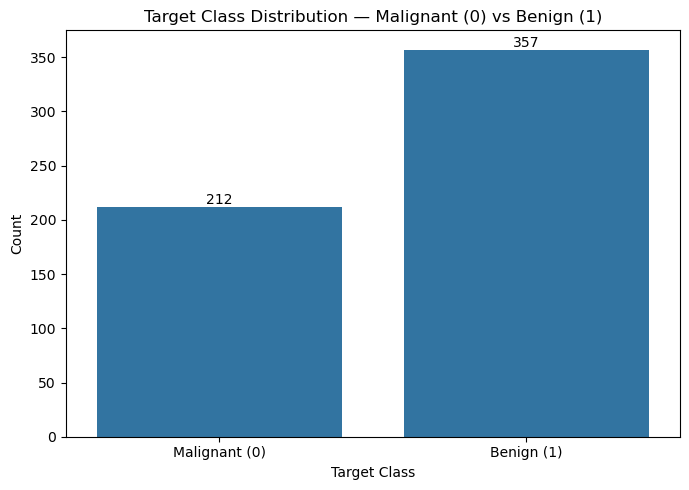

In [3]:
# Task 1.2
plt.figure(figsize=(7, 5))
ax = sns.countplot(x=y, order=[0, 1])
ax.set_title("Target Class Distribution — Malignant (0) vs Benign (1)")
ax.set_xlabel("Target Class")
ax.set_ylabel("Count")
ax.set_xticklabels(["Malignant (0)", "Benign (1)"])
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.tight_layout()
plt.show()

## Task 1.3 — Feature correlation heatmap

The dataset contains strongly correlated groups such as radius, perimeter and area. The heatmap shows these relationships and motivates regularization in later tasks.

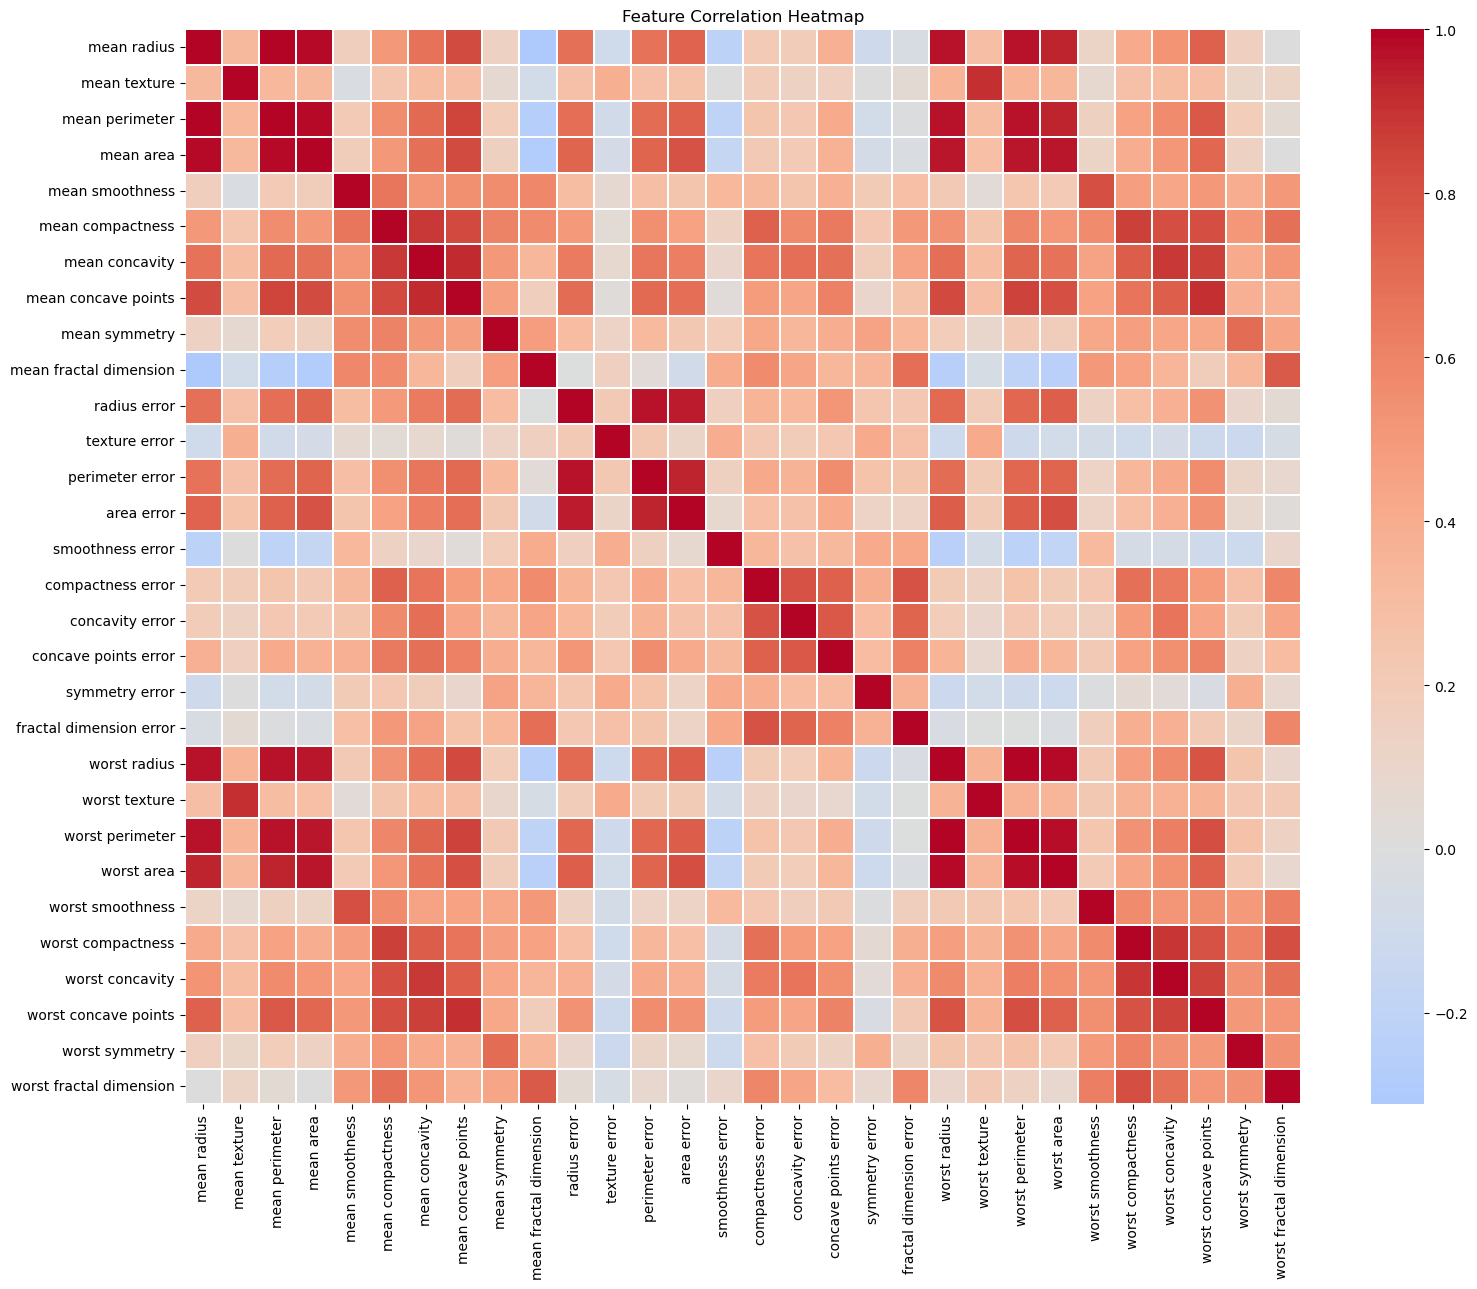

Top 10 absolute feature correlations:
mean radius      mean perimeter     0.997855
worst radius     worst perimeter    0.993708
mean radius      mean area          0.987357
mean perimeter   mean area          0.986507
worst radius     worst area         0.984015
worst perimeter  worst area         0.977578
radius error     perimeter error    0.972794
mean perimeter   worst perimeter    0.970387
mean radius      worst radius       0.969539
mean perimeter   worst radius       0.969476
dtype: float64


In [4]:
# Task 1.3
corr = X.corr()

plt.figure(figsize=(16, 13))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.1)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=np.abs, ascending=False)
)
print("Top 10 absolute feature correlations:")
print(corr_pairs.head(10))

## Task 1.4 — Train/test split

Use an 80/20 split, `random_state=42`, and `stratify=y` so the class proportions are preserved.

In [5]:
# Task 1.4
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining proportions:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest proportions:")
print(y_test.value_counts(normalize=True).sort_index())

X_train: (455, 30)
X_test : (114, 30)
y_train: (455,)
y_test : (114,)

Training proportions:
target
0    0.373626
1    0.626374
Name: proportion, dtype: float64

Test proportions:
target
0    0.368421
1    0.631579
Name: proportion, dtype: float64


## Task 1.5 — Apply StandardScaler

Fit the scaler only on training data and transform both training and test data. This prevents test-set leakage.

In [6]:
# Task 1.5
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Training scaled means (first 5):", np.mean(X_train_sc, axis=0)[:5])
print("Training scaled stds  (first 5):", np.std(X_train_sc, axis=0)[:5])
print("Test scaled means     (first 5):", np.mean(X_test_sc, axis=0)[:5])

Training scaled means (first 5): [-2.92806072e-16  6.24652955e-16 -1.62995380e-16 -1.71779562e-16
  6.24652955e-17]
Training scaled stds  (first 5): [1. 1. 1. 1. 1.]
Test scaled means     (first 5): [0.08578544 0.04796295 0.08516978 0.09195453 0.07160436]


## Task 1.6 — WHY scaling for neural networks?

The scaler must be fitted only on the training set; fitting it on all data would leak information from the test set.

# Task 2: Single-Layer Perceptron (SLP) — Baseline Model

## Task 2.1 — Build the SLP

One sigmoid output neuron and no hidden layers.

In [7]:
# Task 2.1
slp_model = Sequential([
    Input(shape=(30,)),
    Dense(1, activation="sigmoid", name="output")
])
slp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ output (Dense)                  │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

## Task 2.2 — Compile the SLP

Use Adam, binary cross-entropy and accuracy.

In [8]:
# Task 2.2
slp_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
slp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ output (Dense)                  │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

## Task 2.3 — Train the SLP

Train for 50 epochs, batch size 32, validation split 0.1.

In [9]:
# Task 2.3
history_slp = slp_model.fit(
    X_train_sc, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.10,
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.4939 - loss: 0.8112 - val_accuracy: 0.3261 - val_loss: 0.8657
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5868 - loss: 0.7331 - val_accuracy: 0.4783 - val_loss: 0.7958
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6724 - loss: 0.6666 - val_accuracy: 0.5217 - val_loss: 0.7356
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7286 - loss: 0.6107 - val_accuracy: 0.5870 - val_loss: 0.6840
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7555 - loss: 0.5636 - val_accuracy: 0.6304 - val_loss: 0.6395
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7800 - loss: 0.5237 - val_accuracy: 0.6522 - val_loss: 0.6008
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8142 - loss: 0.4894 - val_accuracy: 0.6957 - val_loss: 0.5668
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8386 - loss: 0.4597 - val_accuracy: 0.7826 - v

## Task 2.4 — Plot SLP training curves

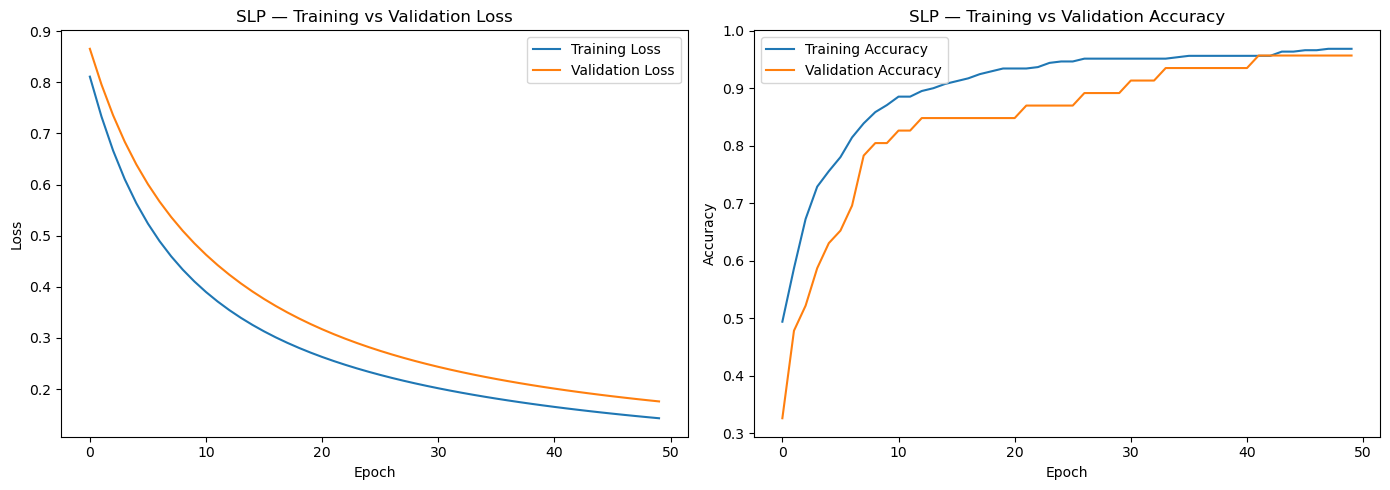

In [10]:
# Task 2.4
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_slp.history["loss"], label="Training Loss")
axes[0].plot(history_slp.history["val_loss"], label="Validation Loss")
axes[0].set_title("SLP — Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_slp.history["accuracy"], label="Training Accuracy")
axes[1].plot(history_slp.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_title("SLP — Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Task 2.5 — Evaluate the SLP

Report test loss/accuracy, classification report and confusion matrix.


SLP
Test Loss:     0.1732
Test Accuracy: 0.9474

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.95      0.90      0.93        42
   Benign (1)       0.95      0.97      0.96        72

     accuracy                           0.95       114
    macro avg       0.95      0.94      0.94       114
 weighted avg       0.95      0.95      0.95       114



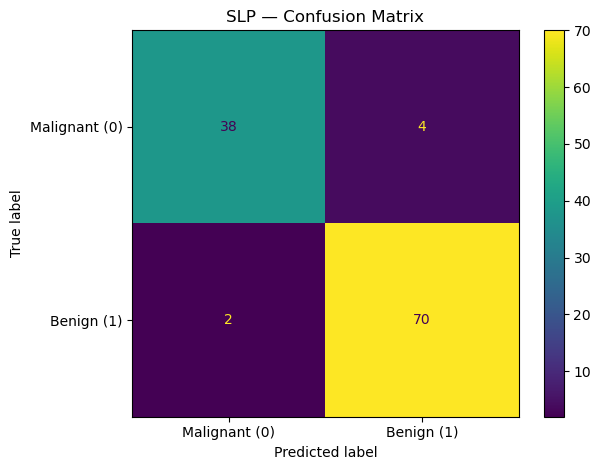

In [11]:
# Task 2.5
def evaluate_binary_model(model, X_eval, y_eval, model_name="Model", threshold=0.5):
    loss, _ = model.evaluate(X_eval, y_eval, verbose=0)
    prob = model.predict(X_eval, verbose=0).ravel()
    pred = (prob >= threshold).astype(int)

    metrics = {
        "Test Accuracy": accuracy_score(y_eval, pred),
        "Test Precision": precision_score(y_eval, pred, zero_division=0),
        "Test Recall": recall_score(y_eval, pred, zero_division=0),
        "Test F1-Score": f1_score(y_eval, pred, zero_division=0),
        "Test Loss": loss
    }

    print(f"\n{model_name}")
    print(f"Test Loss:     {loss:.4f}")
    print(f"Test Accuracy: {metrics['Test Accuracy']:.4f}")
    print("\nClassification Report:")
    print(classification_report(
        y_eval, pred,
        target_names=["Malignant (0)", "Benign (1)"],
        zero_division=0
    ))

    cm = confusion_matrix(y_eval, pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Malignant (0)", "Benign (1)"]
    ).plot(values_format="d")
    plt.title(f"{model_name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return metrics, prob, pred

results = {}

slp_metrics, slp_prob, slp_pred = evaluate_binary_model(
    slp_model, X_test_sc, y_test, "SLP"
)
results["SLP"] = slp_metrics

# Task 3: Multi-Layer Perceptron (MLP) — Activation Functions

## Task 3.1 — Build the MLP (ReLU)

In [12]:
# Task 3.1
mlp_relu = Sequential([
    Input(shape=(30,)),
    Dense(64, activation="relu", name="hidden_1"),
    Dense(32, activation="relu", name="hidden_2"),
    Dense(1, activation="sigmoid", name="output")
])
mlp_relu.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3.2 — WHY hidden layers?

Hidden layers learn intermediate representations of the input. Repeated linear transformations plus non-linear activations allow the network to approximate complex decision boundaries that an SLP cannot represent.

## Task 3.3 — Compile and train MLP (ReLU)

In [13]:
# Task 3.3
mlp_relu.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_mlp_relu = mlp_relu.fit(
    X_train_sc, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.10,
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6968 - loss: 0.5583 - val_accuracy: 0.7826 - val_loss: 0.4866
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9169 - loss: 0.3125 - val_accuracy: 0.8696 - val_loss: 0.3181
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9413 - loss: 0.1989 - val_accuracy: 0.9348 - val_loss: 0.2303
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9535 - loss: 0.1426 - val_accuracy: 0.9565 - val_loss: 0.1781
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9780 - loss: 0.1118 - val_accuracy: 0.9565 - val_loss: 0.1459
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9804 - loss: 0.0931 - val_accuracy: 0.9565 - val_loss: 0.1244
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9804 - loss: 0.0807 - val_accuracy: 0.9565 - val_loss: 0.1094
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9829 - loss: 0.0720 - val_accuracy: 0.

## Task 3.4 — Compare activation functions

Keep the architecture fixed at `64 → 32 → 1` and compare hidden activations:
- sigmoid
- tanh
- ReLU

Train each for 100 epochs.


Training activation = sigmoid

MLP — sigmoid
Test Loss:     0.1040
Test Accuracy: 0.9474

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.89      0.98      0.93        42
   Benign (1)       0.99      0.93      0.96        72

     accuracy                           0.95       114
    macro avg       0.94      0.95      0.94       114
 weighted avg       0.95      0.95      0.95       114



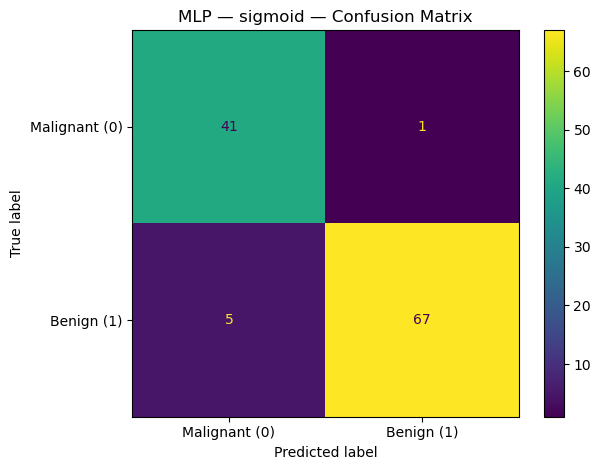


Training activation = tanh

MLP — tanh
Test Loss:     0.1345
Test Accuracy: 0.9561

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.93      0.95      0.94        42
   Benign (1)       0.97      0.96      0.97        72

     accuracy                           0.96       114
    macro avg       0.95      0.96      0.95       114
 weighted avg       0.96      0.96      0.96       114



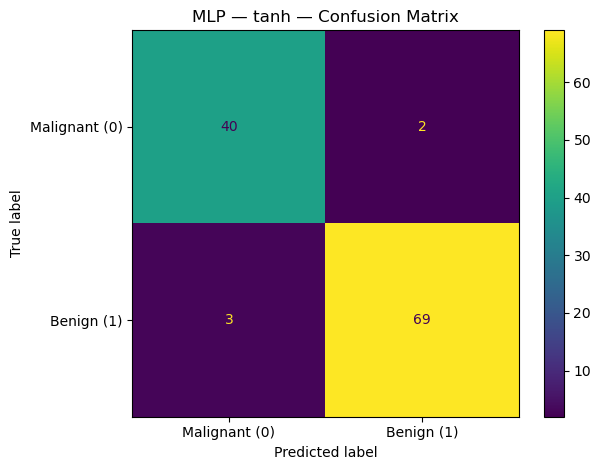


Training activation = relu

MLP — relu
Test Loss:     0.1354
Test Accuracy: 0.9561

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.91      0.98      0.94        42
   Benign (1)       0.99      0.94      0.96        72

     accuracy                           0.96       114
    macro avg       0.95      0.96      0.95       114
 weighted avg       0.96      0.96      0.96       114



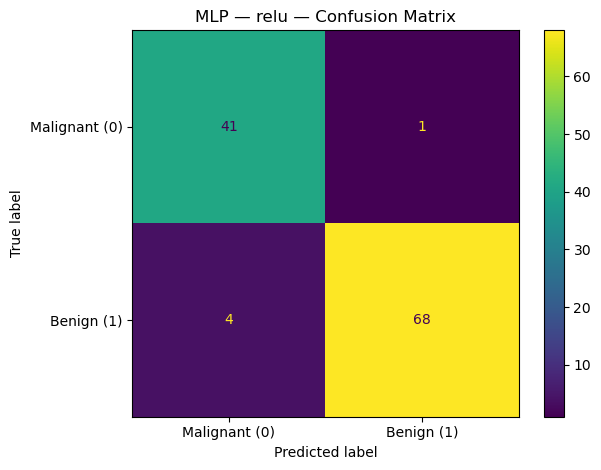

,Final Train Accuracy,Final Validation Accuracy,Best Validation Accuracy,Test Accuracy
sigmoid,0.9902,0.9783,0.9783,0.9474
tanh,1.0000,0.9565,0.9783,0.9561
relu,1.0000,0.9783,1.0000,0.9561


In [14]:
# Task 3.4
def build_activation_model(activation):
    model = Sequential([
        Input(shape=(30,)),
        Dense(64, activation=activation),
        Dense(32, activation=activation),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

activation_models = {}
activation_histories = {}
activation_metrics = {}

for activation in ["sigmoid", "tanh", "relu"]:
    print(f"\nTraining activation = {activation}")
    model = build_activation_model(activation)
    hist = model.fit(
        X_train_sc, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.10,
        verbose=0
    )

    metrics, _, _ = evaluate_binary_model(
        model, X_test_sc, y_test, f"MLP — {activation}"
    )

    activation_models[activation] = model
    activation_histories[activation] = hist
    activation_metrics[activation] = metrics

activation_summary = pd.DataFrame({
    act: {
        "Final Train Accuracy": activation_histories[act].history["accuracy"][-1],
        "Final Validation Accuracy": activation_histories[act].history["val_accuracy"][-1],
        "Best Validation Accuracy": max(activation_histories[act].history["val_accuracy"]),
        "Test Accuracy": activation_metrics[act]["Test Accuracy"]
    }
    for act in activation_histories
}).T

display(activation_summary.round(4))

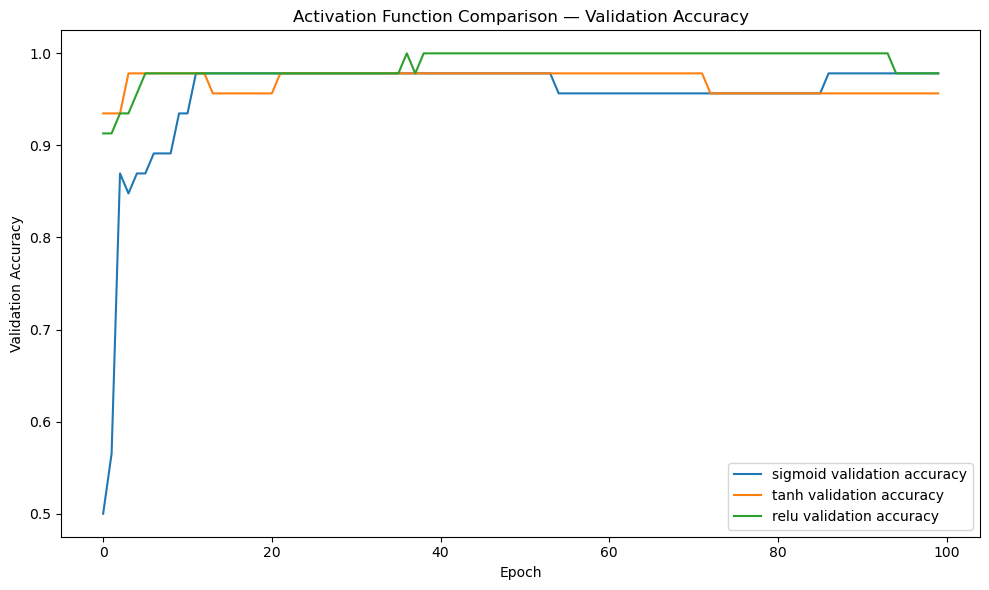

In [15]:
# Task 3.4 — validation-accuracy comparison plot
plt.figure(figsize=(10, 6))
for activation, hist in activation_histories.items():
    plt.plot(hist.history["val_accuracy"], label=f"{activation} validation accuracy")
plt.title("Activation Function Comparison — Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## Task 3.5 — Activation functions Markdown

**ReLU:** `max(0, x)`. It is computationally simple and usually avoids the strong saturation problem of sigmoid/tanh in hidden layers. A possible weakness is the "dead ReLU" problem when neurons remain inactive.

**Tanh:** outputs approximately from -1 to +1 and is zero-centered, but it can saturate and produce small gradients for large inputs.

**Sigmoid:** outputs from 0 to 1 and is excellent for the final binary-classification neuron, but as a hidden activation it can saturate and cause vanishing gradients.

For hidden layers, ReLU is usually the preferred default when its validation/test performance is competitive.

## Task 3.6 — Evaluate the best activation variant

Select the variant with the highest best validation accuracy, then evaluate it on the held-out test set and compare it with the SLP.


Best Activation MLP (relu)
Test Loss:     0.1354
Test Accuracy: 0.9561

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.91      0.98      0.94        42
   Benign (1)       0.99      0.94      0.96        72

     accuracy                           0.96       114
    macro avg       0.95      0.96      0.95       114
 weighted avg       0.96      0.96      0.96       114



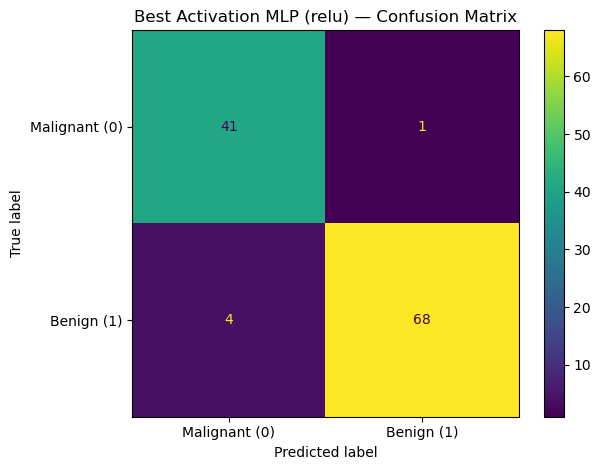

,Model,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,SLP,0.9474,0.9459,0.9722,0.9589
1,MLP-relu,0.9561,0.9855,0.9444,0.9645


In [16]:
# Task 3.6
best_activation = activation_summary["Best Validation Accuracy"].idxmax()
best_activation_model = activation_models[best_activation]

best_activation_metrics, best_activation_prob, best_activation_pred = evaluate_binary_model(
    best_activation_model,
    X_test_sc,
    y_test,
    f"Best Activation MLP ({best_activation})"
)

results[f"MLP-{best_activation}"] = best_activation_metrics

comparison_task3 = pd.DataFrame({
    "Model": ["SLP", f"MLP-{best_activation}"],
    "Test Accuracy": [
        results["SLP"]["Test Accuracy"],
        best_activation_metrics["Test Accuracy"]
    ],
    "Test Precision": [
        results["SLP"]["Test Precision"],
        best_activation_metrics["Test Precision"]
    ],
    "Test Recall": [
        results["SLP"]["Test Recall"],
        best_activation_metrics["Test Recall"]
    ],
    "Test F1-Score": [
        results["SLP"]["Test F1-Score"],
        best_activation_metrics["Test F1-Score"]
    ]
})
display(comparison_task3.round(4))

# Task 4: Early Stopping

## Task 4.1 — Build MLP for Early Stopping

Use `128 → 64 → 1` and intentionally allow up to 300 epochs so overfitting can appear.

In [17]:
# Task 4.1
def build_early_stopping_mlp():
    model = Sequential([
        Input(shape=(30,)),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

mlp_early = build_early_stopping_mlp()
mlp_early.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

## Task 4.2 — Add EarlyStopping callback

In [18]:
# Task 4.2
early_stop_15 = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history_early = mlp_early.fit(
    X_train_sc, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.10,
    callbacks=[early_stop_15],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8826 - loss: 0.4117 - val_accuracy: 0.8913 - val_loss: 0.2744
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9535 - loss: 0.1719 - val_accuracy: 0.9565 - val_loss: 0.1824
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9658 - loss: 0.1087 - val_accuracy: 0.9565 - val_loss: 0.1307
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9829 - loss: 0.0798 - val_accuracy: 0.9783 - val_loss: 0.0963
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9829 - loss: 0.0659 - val_accuracy: 0.9783 - val_loss: 0.0780
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9829 - loss: 0.0576 - val_accuracy: 0.9783 - val_loss: 0.0678
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9853 - loss: 0.0510 - val_accuracy: 0.9783 - val_loss: 0.0607
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9878 - loss: 0.0456 - val_accuracy: 0.

## Task 4.3 — WHY Early Stopping?

If training loss keeps decreasing while validation loss begins increasing, the model is overfitting. EarlyStopping monitors validation loss and stops training when improvement has stopped for the chosen patience period.

With `patience=15`, temporary fluctuations are tolerated. `restore_best_weights=True` restores the weights from the best validation-loss epoch.

## Task 4.4 — Plot Early Stopping

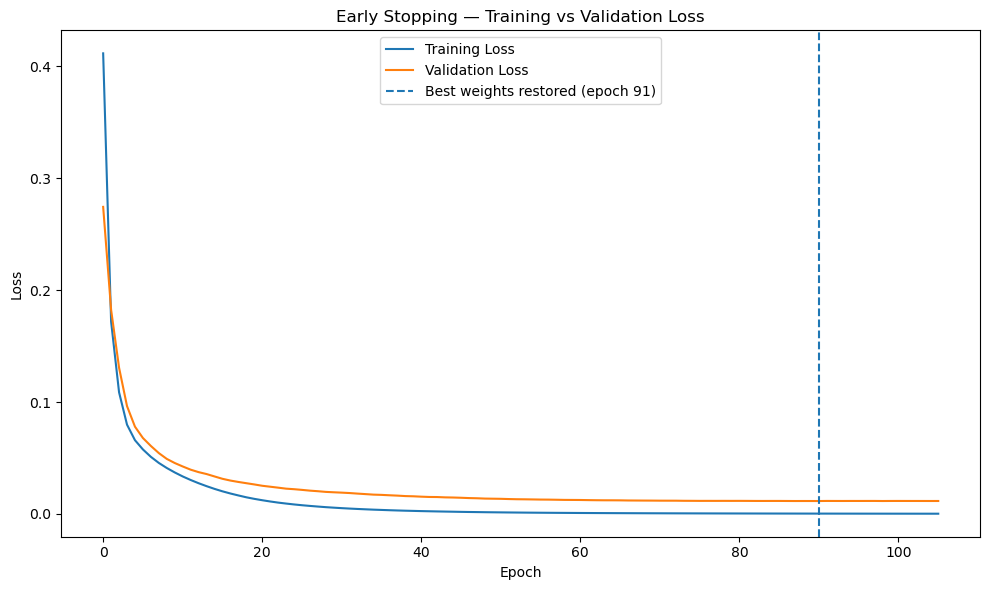

Best validation-loss epoch: 91
Last epoch trained: 106


In [19]:
# Task 4.4
best_epoch_early = int(np.argmin(history_early.history["val_loss"]) + 1)
stopped_epoch_early = len(history_early.history["loss"])

plt.figure(figsize=(10, 6))
plt.plot(history_early.history["loss"], label="Training Loss")
plt.plot(history_early.history["val_loss"], label="Validation Loss")
plt.axvline(
    best_epoch_early - 1,
    linestyle="--",
    label=f"Best weights restored (epoch {best_epoch_early})"
)
plt.title("Early Stopping — Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

print("Best validation-loss epoch:", best_epoch_early)
print("Last epoch trained:", stopped_epoch_early)

## Task 4.5 — Compare with and without Early Stopping

Train an identical model for all 300 epochs without early stopping, then compare validation loss and test accuracy.

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8631 - loss: 0.4420 - val_accuracy: 0.9348 - val_loss: 0.2768
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9535 - loss: 0.1804 - val_accuracy: 0.9130 - val_loss: 0.1830
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9658 - loss: 0.1125 - val_accuracy: 0.9565 - val_loss: 0.1388
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9756 - loss: 0.0842 - val_accuracy: 0.9783 - val_loss: 0.1054
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9804 - loss: 0.0701 - val_accuracy: 0.9783 - val_loss: 0.0853
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9829 - loss: 0.0617 - val_accuracy: 0.9783 - val_loss: 0.0743
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9853 - loss: 0.0551 - val_accuracy: 0.9783 - val_loss: 0.0677
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9902 - loss: 0.0495 - val_accuracy: 0.

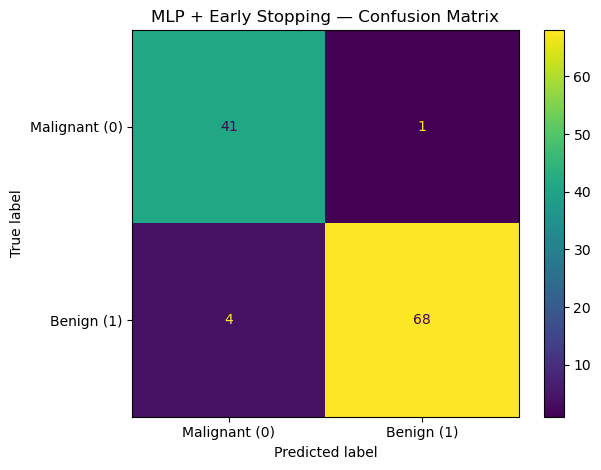


MLP without Early Stopping
Test Loss:     0.2962
Test Accuracy: 0.9474

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.89      0.98      0.93        42
   Benign (1)       0.99      0.93      0.96        72

     accuracy                           0.95       114
    macro avg       0.94      0.95      0.94       114
 weighted avg       0.95      0.95      0.95       114



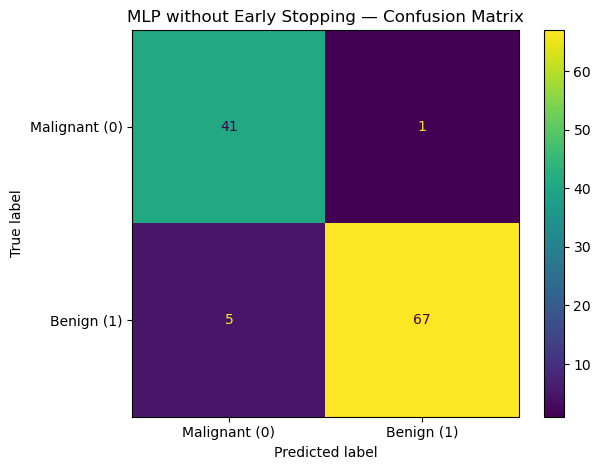

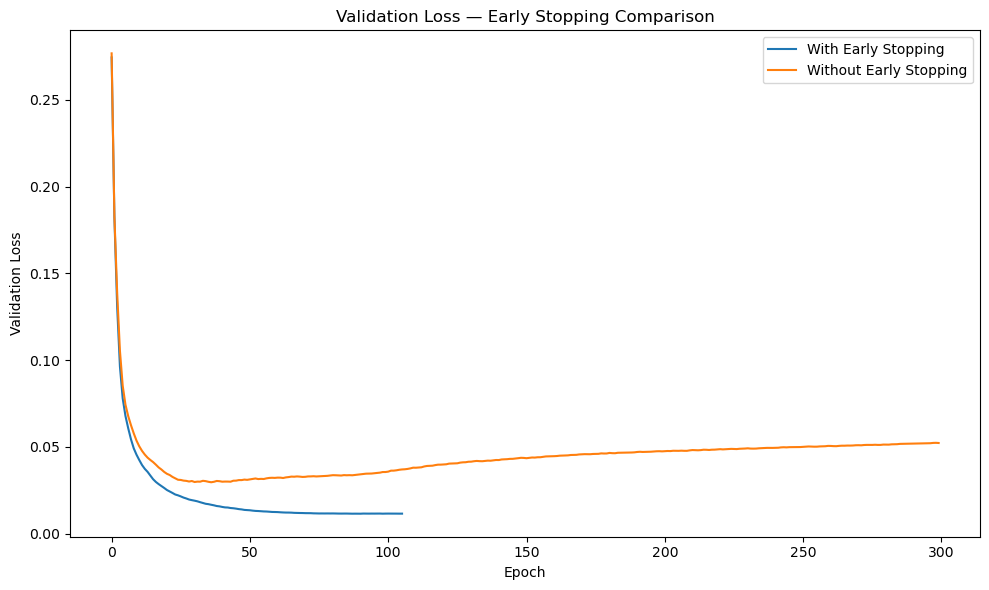

Test accuracy with Early Stopping   : 0.9561
Test accuracy without Early Stopping: 0.9474


In [20]:
# Task 4.5
mlp_no_early = build_early_stopping_mlp()

history_no_early = mlp_no_early.fit(
    X_train_sc, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.10,
    verbose=1
)

early_metrics, _, _ = evaluate_binary_model(
    mlp_early, X_test_sc, y_test, "MLP + Early Stopping"
)
no_early_metrics, _, _ = evaluate_binary_model(
    mlp_no_early, X_test_sc, y_test, "MLP without Early Stopping"
)

results["MLP + Early Stopping"] = early_metrics

plt.figure(figsize=(10, 6))
plt.plot(history_early.history["val_loss"], label="With Early Stopping")
plt.plot(history_no_early.history["val_loss"], label="Without Early Stopping")
plt.title("Validation Loss — Early Stopping Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

print("Test accuracy with Early Stopping   :", round(early_metrics["Test Accuracy"], 4))
print("Test accuracy without Early Stopping:", round(no_early_metrics["Test Accuracy"], 4))

# Task 5: Dropout Layers

## Task 5.1 — Build MLP with Dropout

In [21]:
# Task 5.1
def build_dropout_model(dropout_rate=0.30):
    model = Sequential([
        Input(shape=(30,)),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(64, activation="relu"),
        Dropout(dropout_rate),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

mlp_dropout = build_dropout_model(0.30)
mlp_dropout.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

## Task 5.2 — WHY Dropout?

Dropout randomly removes a fraction of hidden activations during training. A rate of 0.3 means approximately 30% of the selected activations are dropped on each training update.

## Task 5.3 — Train with Dropout + Early Stopping

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7115 - loss: 0.5484 - val_accuracy: 0.8913 - val_loss: 0.3491
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9535 - loss: 0.2572 - val_accuracy: 0.9130 - val_loss: 0.2449
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9487 - loss: 0.1879 - val_accuracy: 0.9348 - val_loss: 0.1839
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9658 - loss: 0.1302 - val_accuracy: 0.9348 - val_loss: 0.1412
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9731 - loss: 0.0959 - val_accuracy: 0.9783 - val_loss: 0.1076
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9682 - loss: 0.1004 - val_accuracy: 0.9565 - val_loss: 0.0914
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9853 - loss: 0.0719 - val_accuracy: 0.9565 - val_loss: 0.0843
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9780 - loss: 0.0695 - val_accuracy: 0.

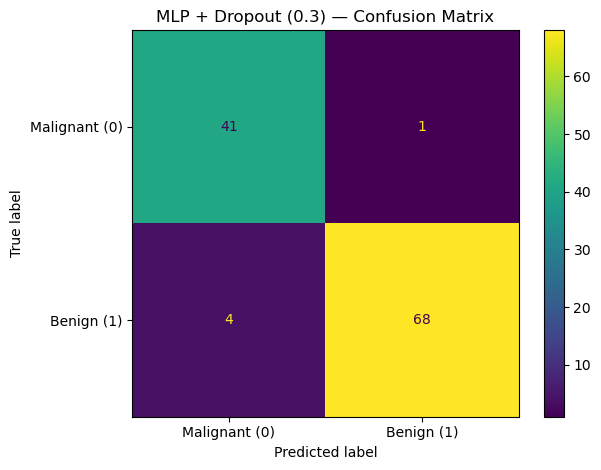

In [22]:
# Task 5.3
early_stop_20 = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_dropout = mlp_dropout.fit(
    X_train_sc, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.10,
    callbacks=[early_stop_20],
    verbose=1
)

dropout_metrics, _, _ = evaluate_binary_model(
    mlp_dropout, X_test_sc, y_test, "MLP + Dropout (0.3)"
)
results["MLP + Dropout (0.3)"] = dropout_metrics

## Task 5.4 — Effect of Dropout Rate

Compare dropout rates `0.1`, `0.3` and `0.5` using the same architecture and EarlyStopping with patience 15.


Training dropout rate = 0.1

Dropout 0.1
Test Loss:     0.1093
Test Accuracy: 0.9561

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.91      0.98      0.94        42
   Benign (1)       0.99      0.94      0.96        72

     accuracy                           0.96       114
    macro avg       0.95      0.96      0.95       114
 weighted avg       0.96      0.96      0.96       114



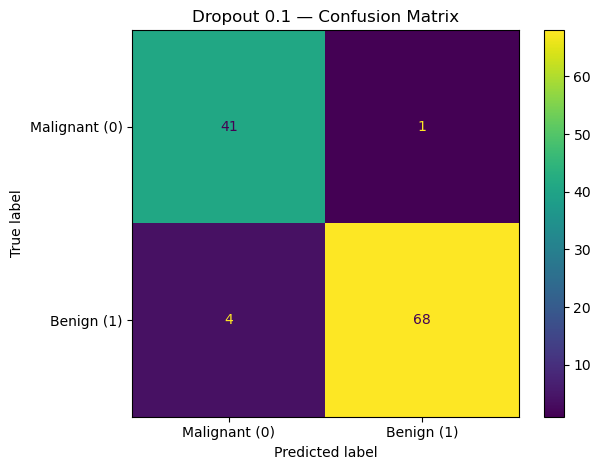


Training dropout rate = 0.3

Dropout 0.3
Test Loss:     0.1337
Test Accuracy: 0.9561

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.91      0.98      0.94        42
   Benign (1)       0.99      0.94      0.96        72

     accuracy                           0.96       114
    macro avg       0.95      0.96      0.95       114
 weighted avg       0.96      0.96      0.96       114



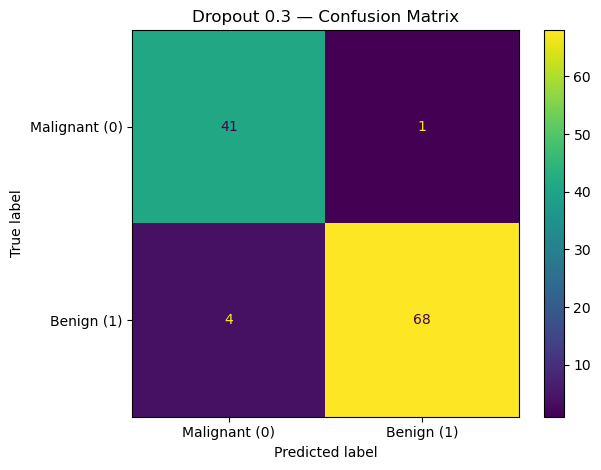


Training dropout rate = 0.5

Dropout 0.5
Test Loss:     0.1441
Test Accuracy: 0.9561

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.91      0.98      0.94        42
   Benign (1)       0.99      0.94      0.96        72

     accuracy                           0.96       114
    macro avg       0.95      0.96      0.95       114
 weighted avg       0.96      0.96      0.96       114



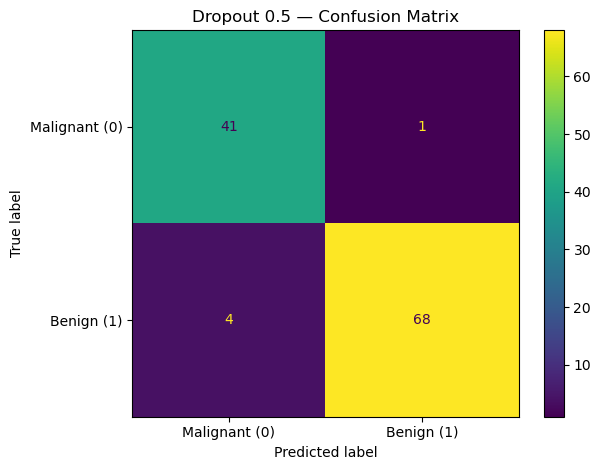

,Dropout Rate,Best Validation Accuracy,Test Accuracy,Test F1-Score,Epochs Trained
0,0.1,1.0,0.9561,0.9645,70
1,0.3,1.0,0.9561,0.9645,71
2,0.5,1.0,0.9561,0.9645,88


Best dropout rate by validation accuracy: 0.1


In [23]:
# Task 5.4
dropout_variants = {}

for rate in [0.1, 0.3, 0.5]:
    print(f"\nTraining dropout rate = {rate}")
    model = build_dropout_model(rate)
    es = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=0
    )

    hist = model.fit(
        X_train_sc, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.10,
        callbacks=[es],
        verbose=0
    )

    test_metrics, _, _ = evaluate_binary_model(
        model, X_test_sc, y_test, f"Dropout {rate}"
    )

    dropout_variants[rate] = {
        "model": model,
        "history": hist,
        "metrics": test_metrics,
        "best_val_accuracy": max(hist.history["val_accuracy"])
    }

dropout_comparison = pd.DataFrame([
    {
        "Dropout Rate": rate,
        "Best Validation Accuracy": item["best_val_accuracy"],
        "Test Accuracy": item["metrics"]["Test Accuracy"],
        "Test F1-Score": item["metrics"]["Test F1-Score"],
        "Epochs Trained": len(item["history"].history["loss"])
    }
    for rate, item in dropout_variants.items()
]).sort_values("Dropout Rate")

display(dropout_comparison.round(4))

best_dropout_rate = float(
    dropout_comparison.loc[
        dropout_comparison["Best Validation Accuracy"].idxmax(),
        "Dropout Rate"
    ]
)
best_dropout_model = dropout_variants[best_dropout_rate]["model"]
best_dropout_metrics = dropout_variants[best_dropout_rate]["metrics"]

print("Best dropout rate by validation accuracy:", best_dropout_rate)

## Task 5.5 — Evaluate the best Dropout model


Best Dropout Model (0.1)
Test Loss:     0.1093
Test Accuracy: 0.9561

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.91      0.98      0.94        42
   Benign (1)       0.99      0.94      0.96        72

     accuracy                           0.96       114
    macro avg       0.95      0.96      0.95       114
 weighted avg       0.96      0.96      0.96       114



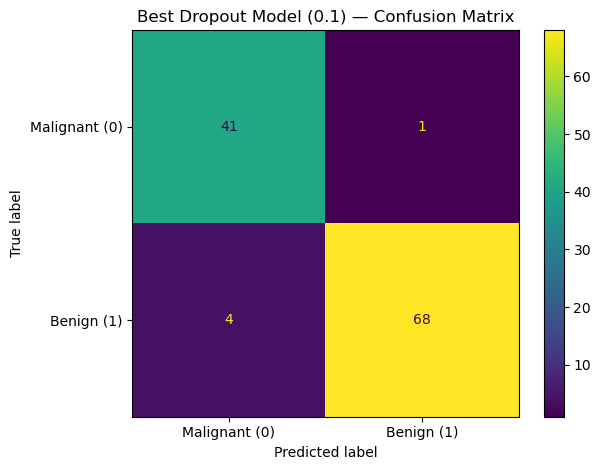

In [24]:
# Task 5.5
best_dropout_metrics, best_dropout_prob, best_dropout_pred = evaluate_binary_model(
    best_dropout_model,
    X_test_sc,
    y_test,
    f"Best Dropout Model ({best_dropout_rate})"
)
results["MLP + Dropout-best"] = best_dropout_metrics

# Task 6: Regularization (L1, L2, L1-L2)

## Task 6.1 — Build MLP with L2 Regularization

Use `l2(0.001)` on the two hidden layers and train with EarlyStopping.

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7066 - loss: 0.6525 - val_accuracy: 0.8478 - val_loss: 0.5259
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9169 - loss: 0.3703 - val_accuracy: 0.9130 - val_loss: 0.3778
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9389 - loss: 0.2732 - val_accuracy: 0.9130 - val_loss: 0.3135
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9584 - loss: 0.2272 - val_accuracy: 0.9348 - val_loss: 0.2714
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9658 - loss: 0.2003 - val_accuracy: 0.9348 - val_loss: 0.2390
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9804 - loss: 0.1824 - val_accuracy: 0.9565 - val_loss: 0.2134
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9804 - loss: 0.1699 - val_accuracy: 0.9565 - val_loss: 0.1949
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9804 - loss: 0.1606 - val_accuracy: 0.

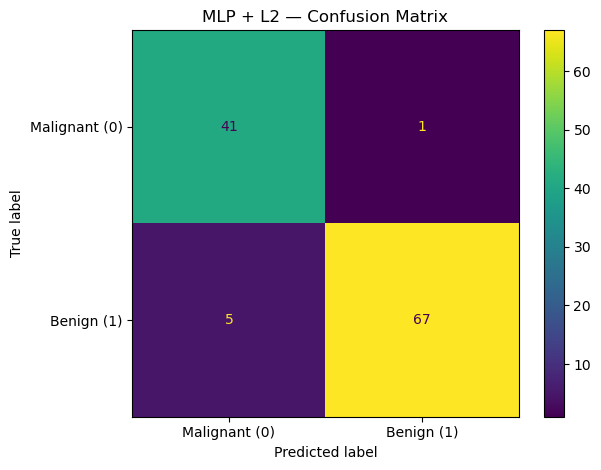

In [25]:
# Task 6.1
def build_regularized_model(kind):
    if kind == "l2":
        reg = regularizers.l2(0.001)
    elif kind == "l1":
        reg = regularizers.l1(0.001)
    elif kind == "l1_l2":
        reg = regularizers.l1_l2(l1=0.001, l2=0.001)
    else:
        raise ValueError("kind must be l1, l2 or l1_l2")

    model = Sequential([
        Input(shape=(30,)),
        Dense(64, activation="relu", kernel_regularizer=reg),
        Dense(32, activation="relu", kernel_regularizer=reg),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

model_l2 = build_regularized_model("l2")
model_l2.summary()

history_l2 = model_l2.fit(
    X_train_sc, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.10,
    callbacks=[EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    )],
    verbose=1
)

metrics_l2, _, _ = evaluate_binary_model(
    model_l2, X_test_sc, y_test, "MLP + L2"
)
results["MLP + L2"] = metrics_l2

## Task 6.2 — WHY L2 Regularization?

L2 adds a penalty proportional to squared weights:

**Regularized Loss = Loss + λ Σ w²**

This discourages very large weights and often improves generalization. It is especially useful when predictors are correlated because it can distribute the predictive contribution across related variables rather than relying too strongly on a few weights.

## Task 6.3 — Build MLP with L1 Regularization

Use the same architecture and `l1(0.001)`.

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8020 - loss: 1.0173 - val_accuracy: 0.8913 - val_loss: 0.8731
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9462 - loss: 0.7648 - val_accuracy: 0.9348 - val_loss: 0.7428
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9609 - loss: 0.6534 - val_accuracy: 0.9348 - val_loss: 0.6803
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9633 - loss: 0.5996 - val_accuracy: 0.9348 - val_loss: 0.6367
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9707 - loss: 0.5664 - val_accuracy: 0.9348 - val_loss: 0.6007
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9756 - loss: 0.5417 - val_accuracy: 0.9565 - val_loss: 0.5709
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9829 - loss: 0.5212 - val_accuracy: 0.9783 - val_loss: 0.5461
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9853 - loss: 0.5029 - val_accuracy: 0.

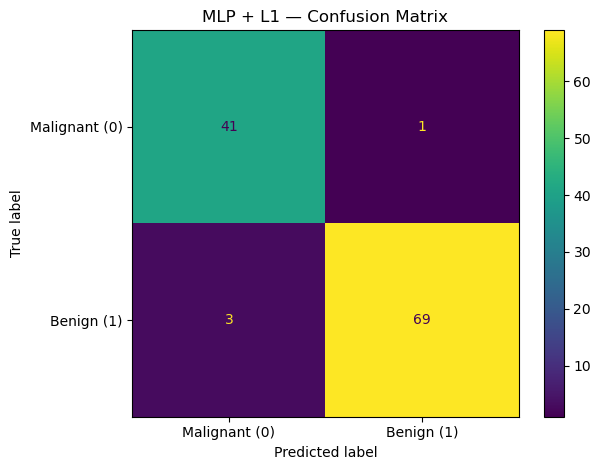

In [26]:
# Task 6.3
model_l1 = build_regularized_model("l1")

history_l1 = model_l1.fit(
    X_train_sc, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.10,
    callbacks=[EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    )],
    verbose=1
)

metrics_l1, _, _ = evaluate_binary_model(
    model_l1, X_test_sc, y_test, "MLP + L1"
)
results["MLP + L1"] = metrics_l1

## Task 6.4 — Build MLP with L1-L2 (ElasticNet)

Use `l1_l2(l1=0.001, l2=0.001)`. L1 encourages sparse weights while L2 discourages excessively large weights.

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8582 - loss: 1.0668 - val_accuracy: 0.9130 - val_loss: 0.9850
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9340 - loss: 0.8532 - val_accuracy: 0.9130 - val_loss: 0.8345
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9487 - loss: 0.7429 - val_accuracy: 0.9348 - val_loss: 0.7488
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9633 - loss: 0.6817 - val_accuracy: 0.9783 - val_loss: 0.6911
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9707 - loss: 0.6412 - val_accuracy: 0.9783 - val_loss: 0.6471
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9756 - loss: 0.6097 - val_accuracy: 0.9783 - val_loss: 0.6111
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9756 - loss: 0.5824 - val_accuracy: 0.9783 - val_loss: 0.5804
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9829 - loss: 0.5575 - val_accuracy: 0.

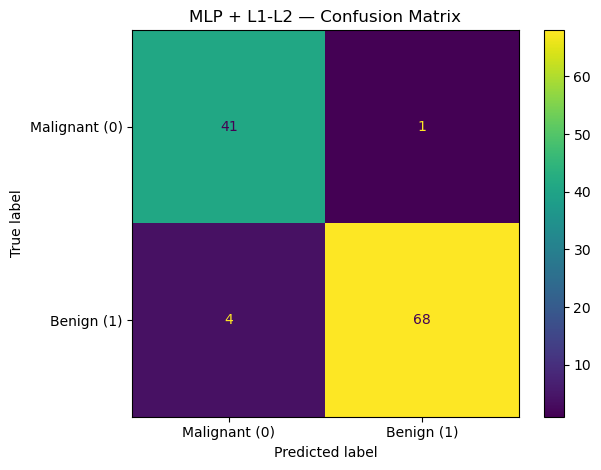

In [27]:
# Task 6.4
model_l1_l2 = build_regularized_model("l1_l2")

history_l1_l2 = model_l1_l2.fit(
    X_train_sc, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.10,
    callbacks=[EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    )],
    verbose=1
)

metrics_l1_l2, _, _ = evaluate_binary_model(
    model_l1_l2, X_test_sc, y_test, "MLP + L1-L2"
)
results["MLP + L1-L2"] = metrics_l1_l2

## Task 6.5 — Regularization comparison plot

Create the requested **1×3 figure** using the same y-axis scale:
- L1
- L2
- L1-L2

Title: **Regularization Comparison — Training vs Validation Loss**

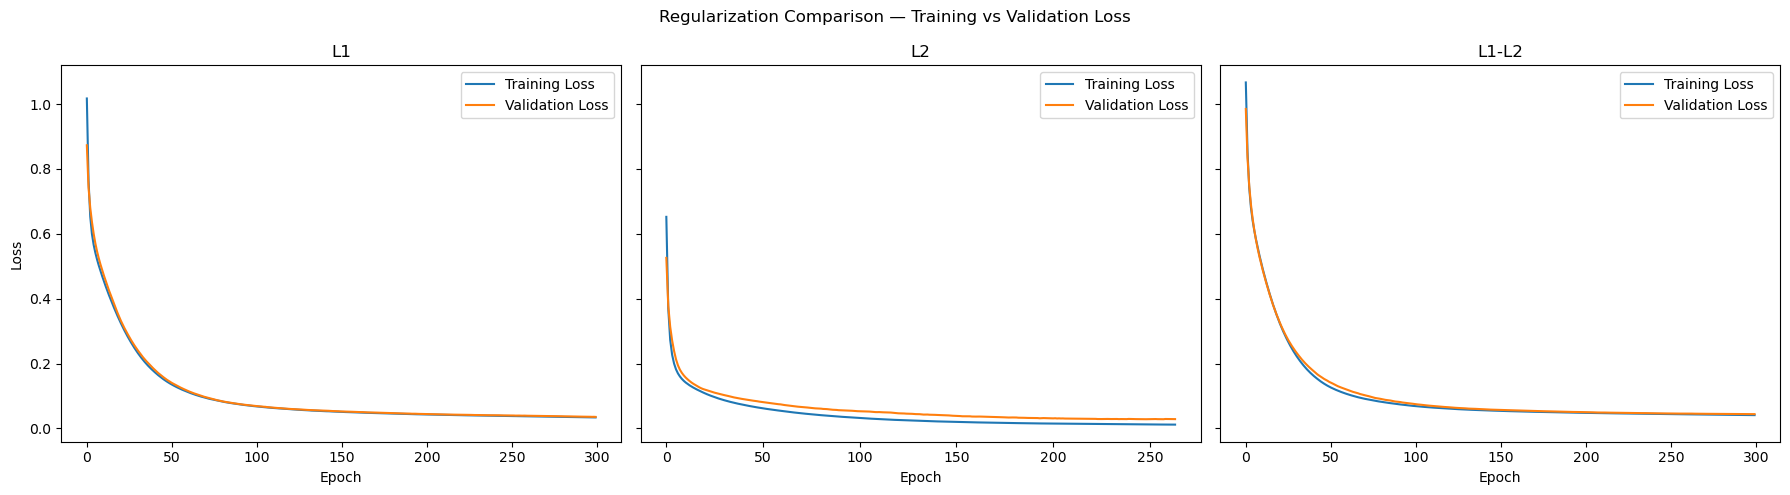

In [28]:
# Task 6.5
histories_reg = {
    "L1": history_l1,
    "L2": history_l2,
    "L1-L2": history_l1_l2
}

all_loss_values = []
for hist in histories_reg.values():
    all_loss_values.extend(hist.history["loss"])
    all_loss_values.extend(hist.history["val_loss"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (name, hist) in zip(axes, histories_reg.items()):
    ax.plot(hist.history["loss"], label="Training Loss")
    ax.plot(hist.history["val_loss"], label="Validation Loss")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.legend()

axes[0].set_ylabel("Loss")
fig.suptitle("Regularization Comparison — Training vs Validation Loss")
plt.tight_layout()
plt.show()

## Task 6.6 — Evaluate all three regularized models

Compare L1, L2 and L1-L2 against the best unregularized MLP from Task 3.

,Model,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,No Regularization (Task 3),0.9561,0.9855,0.9444,0.9645
1,L1,0.9649,0.9857,0.9583,0.9718
2,L2,0.9474,0.9853,0.9306,0.9571
3,L1-L2,0.9561,0.9855,0.9444,0.9645


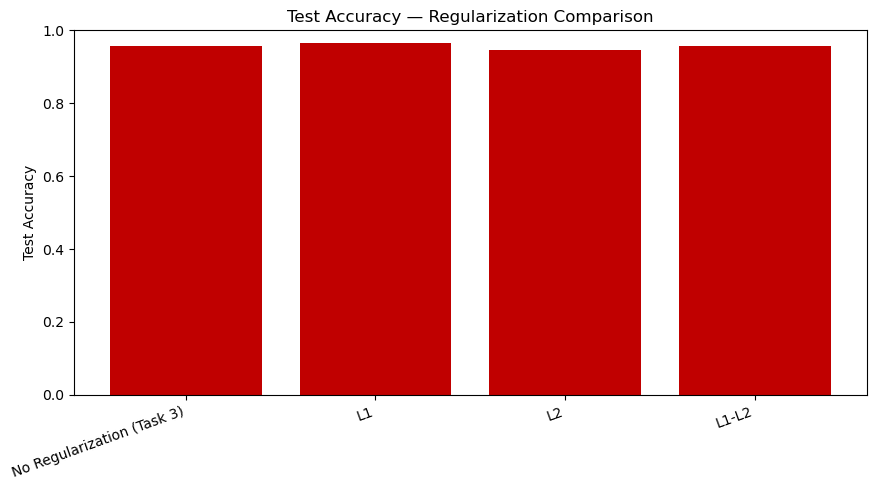

In [29]:
# Task 6.6
reg_results = pd.DataFrame([
    {"Model": "No Regularization (Task 3)", **best_activation_metrics},
    {"Model": "L1", **metrics_l1},
    {"Model": "L2", **metrics_l2},
    {"Model": "L1-L2", **metrics_l1_l2}
])

display(reg_results[
    ["Model", "Test Accuracy", "Test Precision", "Test Recall", "Test F1-Score"]
].round(4))

plt.figure(figsize=(9, 5))
plt.bar(
    reg_results["Model"],
    reg_results["Test Accuracy"],
    color="#C00000"
)
plt.title("Test Accuracy — Regularization Comparison")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Task 7: Final Comparison, Business Insights & Notebook Quality

## Task 7.1 — Final model: combine the best techniques from Tasks 4–6

Required architecture:

`Dense(128, relu, L2) → Dropout(0.3) → Dense(64, relu, L2) → Dropout(0.3) → Dense(1, sigmoid)`

Train with EarlyStopping using `patience=20` and `restore_best_weights=True`.

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_128_l2 (Dense)            │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30_a (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64_l2 (Dense)             │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30_b (Dropout)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8117 - loss: 0.6274 - val_accuracy: 0.9348 - val_loss: 0.4581
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9511 - loss: 0.3755 - val_accuracy: 0.9348 - val_loss: 0.3433
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9609 - loss: 0.2796 - val_accuracy: 0.9565 - val_loss: 0.2913
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9682 - loss: 0.2453 - val_accuracy: 0.9565 - val_loss: 0.2562
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9682 - loss: 0.2226 - val_accuracy: 0.9565 - val_loss: 0.2316
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9829 - loss: 0.2071 - val_accuracy: 0.9565 - val_loss: 0.2128
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9731 - loss: 0.1953 - val_accuracy: 0.9565 - val_loss: 0.2015
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9829 - loss: 0.1824 - val_accuracy: 0.

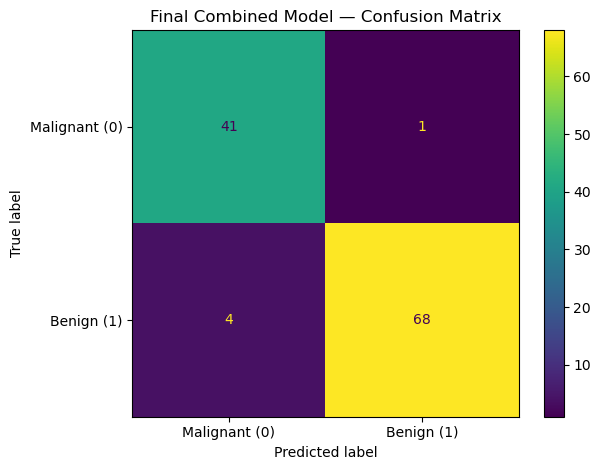

Final model best validation-loss epoch: 127


In [30]:
# Task 7.1
final_model = Sequential([
    Input(shape=(30,)),
    Dense(
        128, activation="relu",
        kernel_regularizer=regularizers.l2(0.001),
        name="dense_128_l2"
    ),
    Dropout(0.3, name="dropout_30_a"),
    Dense(
        64, activation="relu",
        kernel_regularizer=regularizers.l2(0.001),
        name="dense_64_l2"
    ),
    Dropout(0.3, name="dropout_30_b"),
    Dense(1, activation="sigmoid", name="output")
])

final_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
final_model.summary()

final_early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_final = final_model.fit(
    X_train_sc, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.10,
    callbacks=[final_early_stop],
    verbose=1
)

final_metrics, final_prob, final_pred = evaluate_binary_model(
    final_model, X_test_sc, y_test, "Final Combined Model"
)
results["Final Combined Model"] = final_metrics

print(
    "Final model best validation-loss epoch:",
    int(np.argmin(history_final.history["val_loss"]) + 1)
)

## Task 7.2 — Full results comparison

Build one pandas DataFrame with the required columns and one row per required model:
SLP, MLP-ReLU, MLP + Early Stopping, MLP + Dropout-best, MLP + L2 and Final Combined Model.


MLP-ReLU (Task 3)
Test Loss:     0.1604
Test Accuracy: 0.9561

Classification Report:
               precision    recall  f1-score   support

Malignant (0)       0.91      0.98      0.94        42
   Benign (1)       0.99      0.94      0.96        72

     accuracy                           0.96       114
    macro avg       0.95      0.96      0.95       114
 weighted avg       0.96      0.96      0.96       114



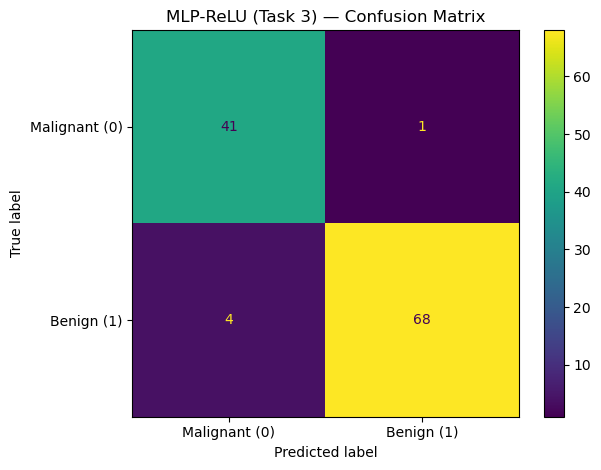

,Model,Architecture,Regularization,Dropout Rate,Early Stopping,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,SLP (Task 2),30 → 1 sigmoid,None,0.0,No,0.9474,0.9459,0.9722,0.9589
1,MLP-ReLU (Task 3),30 → 64 ReLU → 32 ReLU → 1 sigmoid,None,0.0,No,0.9561,0.9855,0.9444,0.9645
2,MLP + Early Stopping (Task 4),30 → 128 ReLU → 64 ReLU → 1 sigmoid,None,0.0,Yes (15),0.9561,0.9855,0.9444,0.9645
3,MLP + Dropout-best (Task 5),30 → 128 ReLU → Dropout → 64 ReLU → Dropout → 1 sigmoid,None,0.1,Yes (15),0.9561,0.9855,0.9444,0.9645
4,MLP + L2 (Task 6),30 → 64 ReLU → 32 ReLU → 1 sigmoid,L2=0.001,0.0,Yes (15),0.9474,0.9853,0.9306,0.9571
5,Final Combined Model (Task 7.1),30 → 128 ReLU → Dropout → 64 ReLU → Dropout → 1 sigmoid,L2=0.001,0.3,Yes (20),0.9561,0.9855,0.9444,0.9645


,Model,Architecture,Regularization,Dropout Rate,Early Stopping,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,SLP (Task 2),30 → 1 sigmoid,None,0.0,No,0.947368,0.945946,0.972222,0.958904
1,MLP-ReLU (Task 3),30 → 64 ReLU → 32 ReLU → 1 sigmoid,None,0.0,No,0.956140,0.985507,0.944444,0.964539
2,MLP + Early Stopping (Task 4),30 → 128 ReLU → 64 ReLU → 1 sigmoid,None,0.0,Yes (15),0.956140,0.985507,0.944444,0.964539
3,MLP + Dropout-best (Task 5),30 → 128 ReLU → Dropout → 64 ReLU → Dropout → ...,None,0.1,Yes (15),0.956140,0.985507,0.944444,0.964539
4,MLP + L2 (Task 6),30 → 64 ReLU → 32 ReLU → 1 sigmoid,L2=0.001,0.0,Yes (15),0.947368,0.985294,0.930556,0.957143
5,Final Combined Model (Task 7.1),30 → 128 ReLU → Dropout → 64 ReLU → Dropout → ...,L2=0.001,0.3,Yes (20),0.956140,0.985507,0.944444,0.964539


In [31]:
# Task 7.2
def metric_row(name, architecture, regularization, dropout_rate,
               early_stopping, metrics):
    return {
        "Model": name,
        "Architecture": architecture,
        "Regularization": regularization,
        "Dropout Rate": dropout_rate,
        "Early Stopping": early_stopping,
        "Test Accuracy": metrics["Test Accuracy"],
        "Test Precision": metrics["Test Precision"],
        "Test Recall": metrics["Test Recall"],
        "Test F1-Score": metrics["Test F1-Score"]
    }

mlp_relu_metrics, _, _ = evaluate_binary_model(
    mlp_relu, X_test_sc, y_test, "MLP-ReLU (Task 3)"
)

comparison_rows = [
    metric_row(
        "SLP (Task 2)",
        "30 → 1 sigmoid",
        "None", 0.0, "No", results["SLP"]
    ),
    metric_row(
        "MLP-ReLU (Task 3)",
        "30 → 64 ReLU → 32 ReLU → 1 sigmoid",
        "None", 0.0, "No", mlp_relu_metrics
    ),
    metric_row(
        "MLP + Early Stopping (Task 4)",
        "30 → 128 ReLU → 64 ReLU → 1 sigmoid",
        "None", 0.0, "Yes (15)", early_metrics
    ),
    metric_row(
        "MLP + Dropout-best (Task 5)",
        "30 → 128 ReLU → Dropout → 64 ReLU → Dropout → 1 sigmoid",
        "None", best_dropout_rate, "Yes (15)", best_dropout_metrics
    ),
    metric_row(
        "MLP + L2 (Task 6)",
        "30 → 64 ReLU → 32 ReLU → 1 sigmoid",
        "L2=0.001", 0.0, "Yes (15)", metrics_l2
    ),
    metric_row(
        "Final Combined Model (Task 7.1)",
        "30 → 128 ReLU → Dropout → 64 ReLU → Dropout → 1 sigmoid",
        "L2=0.001", 0.3, "Yes (20)", final_metrics
    )
]

results_df = pd.DataFrame(comparison_rows)

display(
    results_df.style
    .format({
        "Dropout Rate": "{:.1f}",
        "Test Accuracy": "{:.4f}",
        "Test Precision": "{:.4f}",
        "Test Recall": "{:.4f}",
        "Test F1-Score": "{:.4f}"
    })
    .highlight_max(
        subset=["Test Accuracy", "Test F1-Score"],
        color="#F0CCCC"
    )
)

results_df

## Task 7.3 — Business/clinical insight report

Because this is a medical-diagnosis dataset, recall for the malignant class deserves particular attention: a false negative can mean a malignant case is missed.

The following cell creates the requested structured Markdown report from the actual experiment results. A threshold of 0.5 is only a baseline; in real deployment the threshold should be selected using validation data, precision-recall analysis and explicit clinical costs.

**Educational disclaimer:** the models in this notebook are not clinically validated diagnostic tools.

## Task 7.4 — `requirements.txt`

The required environment contains TensorFlow/Keras, scikit-learn, pandas, NumPy, Matplotlib, Seaborn and Jupyter.